# Dynamics and Predictive Power of the Variance Risk Premium in S&P500 Options

In [1]:
#import sys
#!{sys.executable} -m pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 

from utilities.clean_data import load_and_clean
from utilities.compute_IV import bs_price, implied_vol, compute_iv_surface
from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
RISK_FREE     = 0.02            # constant risk-free rate (US 1Y T-bill ~2% in 2017-18)
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Black-Scholes pricing & implied volatility

### 1.1 Theoretical background

The **Black-Scholes** formula prices a European option under the assumptions of:
- Log-normal dynamics for the underlying: $dS = \mu S\,dt + \sigma S\,dW_t$
- Constant volatility $\sigma$, constant risk-free rate $r$, no dividends

$$C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Implied volatility** $\hat\sigma$ is the value of $\sigma$ that equates the model price to the observed market price:

$$\hat\sigma = \{\sigma : \text{BS}(S,K,T,\hat{r},\sigma) = C^{\text{mkt}}\}$$

where $\hat{r}$ is the **implied discount rate** extracted per (date, expiry) via put-call parity regression (see Section 2.3), rather than a fixed constant.

We solve this numerically using **Brent's method** (bracketed root-finding, guaranteed convergence).


In [4]:
# ── Quick sanity check ─────────────────────────────────────────────────────────
S_test, K_test, T_test, r_test, sig_test = 100, 100, 0.25, 0.02, 0.20
price_test = bs_price(S_test, K_test, T_test, r_test, sig_test, 'C')
iv_back    = implied_vol(price_test, S_test, K_test, T_test, r_test, 'C')
print(f"BS price (ATM call, σ=20%): {price_test:.4f}")
print(f"Recovered IV:               {iv_back*100:.4f}%  ← should be 20.0000%")
assert abs(iv_back - sig_test) < 1e-5, "IV inversion failed!"
print("Black-Scholes & IV inversion validated")


BS price (ATM call, σ=20%): 4.2322
Recovered IV:               20.0000%  ← should be 20.0000%
Black-Scholes & IV inversion validated


## 2 · Data loading & cleaning

### 2.1 Dataset
Each daily file contains all listed SPX options for that trading date.
Columns: `date`, `ask`, `bid`, `strike`, `open_interest`, `exp_date`, `type (C/P)`.
The dataset spans **253 trading days** (Jun 2017 – Jun 2018) with ~1,500 contracts/day.

### 2.2 Cleaning
1. Parse dates, compute $T = (\text{expiry} - \text{date}) / 365$
2. Compute mid price: $P^{\text{mid}} = (\text{ask} + \text{bid}) / 2$
3. Drop options with $T < 7$ days (expiry noise)
4. Drop options with relative bid-ask spread $> 50\%$ (illiquid)

### 2.3 Spot & discount factor — implicit regression on put-call parity

Instead of applying put-call parity strike by strike with a fixed risk-free rate,
we exploit the **linear structure** of put-call parity across strikes (Brenner & Galai, 1986).

For a given (date, expiry) pair:

$$C - P = B \cdot (F - K) \implies \underbrace{C-P}_{G} = \underbrace{BF}_{\text{intercept}} - \underbrace{B}_{\text{slope}} \cdot K$$

Fitting this regression across all strikes gives:

$$\hat{B} = -\hat{b}, \quad \hat{F} = \frac{\hat{a}}{\hat{B}}, \quad \hat{S} = \hat{F}\cdot\hat{B}, \quad \hat{r} = -\frac{\ln\hat{B}}{T}$$

**Three outputs per (date, expiry):** implicit discount factor $\hat{B}$, forward price $\hat{F}$,
and implied rate $\hat{r}$ — used in Black-Scholes instead of a fixed rate.

Log-moneyness is defined as $\log(K/\hat{F})$ (forward log-moneyness): the smile is
naturally centered on the forward price under no-arbitrage models.


In [5]:
df_raw = load_and_clean(DATA_FOLDER)
df_raw.head(3)

Loading 253 files...
✓ Rows after cleaning : 355,202
  Trading days        : 253
  Unique expiries     : 22
  Spot range          : 2382 – 2839
  Implied r (mean)    : 2.07%  


,date,date2,ask,bid,strike,oi,strike2,high,low,open,...,type,T,mid,ba_rel,spot,F_impl,B_impl,r_impl,log_m,r
0,2017-06-08,2017-06-08,1326.4,1306.7,1100.0,400.0,1100,1316.55,1316.55,1316.55,...,C,0.616438,1316.55,0.014963,2407.87278,2428.718439,0.991417,0.013984,-0.792054,0.013984
1,2017-06-08,2017-06-08,1301.7,1282.0,1125.0,0.0,1125,1291.85,1291.85,1291.85,...,C,0.616438,1291.85,0.015249,2407.87278,2428.718439,0.991417,0.013984,-0.769581,0.013984
2,2017-06-08,2017-06-08,1277.0,1257.3,1150.0,0.0,1150,1267.15,1267.15,1267.15,...,C,0.616438,1267.15,0.015547,2407.87278,2428.718439,0.991417,0.013984,-0.747602,0.013984


In [6]:
# Comparer les données brutes
print(f"Nombre de fichiers : {len(glob.glob('./data/*.csv'))}")
print(f"Lignes totales     : {len(df_raw)}")
print(df_raw[['mid', 'strike', 'spot']].describe().round(4))

Nombre de fichiers : 253
Lignes totales     : 355202
               mid       strike         spot
count  355202.0000  355202.0000  355202.0000
mean      383.7882    2195.0926    2586.4779
std       422.4170     576.3179     114.3527
min         0.0500    1100.0000    2382.1965
25%        28.8500    1750.0000    2473.2121
50%       205.3500    2175.0000    2603.1908
75%       656.5000    2625.0000    2679.8805
max      1771.0500    4000.0000    2838.9295


## 3 · IV surface computation

We compute the IV for every option row.  
**Note**: for deep ITM options the BS formula becomes ill-conditioned (very high vega sensitivity).  
We restrict to forward log-moneyness $\log(K/F) \in [-0.6,\, 0.4]$ and discard IVs outside $[1\%,\, 200\%]$.  
Options with missing implied rate $\hat{r}$ (failed put-call parity regression) are discarded.

This is the most computationally intensive step (~5-10 min for the full year).  
Progress is printed every 10,000 rows.


In [7]:
import os
import pickle
import pandas as pd

CACHE_PICKLE = "iv_surface.pkl"
CACHE_PARQUET = "iv_surface.parquet"

df = None

# try for pickle
if os.path.exists(CACHE_PICKLE):
    try:
        print(f"🔄 try to load pickle : '{CACHE_PICKLE}'...")
        with open(CACHE_PICKLE, 'rb') as f:
            df = pickle.load(f)
        print(f"✓ Success ! Data loaded via Pickle ({len(df):,} lines)")
    except (TypeError, AttributeError, ValueError) as e:
        print(f"❌ Failed to load Pickle (Version incompatibility detected : {e})")
        print("🔄 Automatic fallback to the backup method Parquet...")

# second chance with Parquet
if df is None:
    if os.path.exists(CACHE_PARQUET):
        print(f"📦 Reading from '{CACHE_PARQUET}'...")
        df = pd.read_parquet(CACHE_PARQUET)
        print(f"✓ Success ! Data loaded via Parquet ({len(df):,} lines)")
    else:
        print("⚠️ No valid cache found (Neither Pickle nor Parquet). Launching computation...")
        
        if 'df_raw' not in locals() and 'df_raw' not in globals():
            df_raw = load_and_clean(DATA_FOLDER)
            
        df = compute_iv_surface(df_raw)
        
        print(f"💾 Saving Parquet cache locally in '{CACHE_PARQUET}'...")
        df.to_parquet(CACHE_PARQUET, index=True)

df.head(3)

🔄 try to load pickle : 'iv_surface.pkl'...
❌ Failed to load Pickle (Version incompatibility detected : StringDtype.__init__() takes from 1 to 2 positional arguments but 3 were given)
🔄 Automatic fallback to the backup method Parquet...
📦 Reading from 'iv_surface.parquet'...
✓ Success ! Data loaded via Parquet (263,064 lines)


,date,date2,ask,bid,strike,oi,strike2,high,low,open,...,T,mid,ba_rel,spot,F_impl,B_impl,r_impl,log_m,r,iv
9,2017-06-08,2017-06-08,1055.2,1035.2,1375.0,0.0,1375,1045.20,1045.20,1045.20,...,0.616438,1045.20,0.019135,2407.87278,2428.718439,0.991417,0.013984,-0.568910,0.013984,0.275902
10,2017-06-08,2017-06-08,1030.7,1010.6,1400.0,7.0,1400,1020.65,1020.65,1020.65,...,0.616438,1020.65,0.019693,2407.87278,2428.718439,0.991417,0.013984,-0.550891,0.013984,0.278938
11,2017-06-08,2017-06-08,981.5,962.3,1450.0,0.0,1450,971.90,971.90,971.90,...,0.616438,971.90,0.019755,2407.87278,2428.718439,0.991417,0.013984,-0.515800,0.013984,0.287120


## 4 · Volatility smile & surface

### 4.1 The smile

Under Black-Scholes, IV should be **constant** across strikes.  
In practice it is not — OTM puts are more expensive (higher IV) than OTM calls:
- Investors pay an **insurance premium** against left-tail crashes
- This creates the characteristic left-skewed smile observed for equity indices

### 4.2 Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **ATM IV** | IV at $\log(K/F) \approx 0$ | Overall level of market fear |
| **Skew** | IV(put wing) − IV(call wing) | Asymmetry / demand for downside protection |
| **Convexity** | $\frac{IV_{put} + IV_{call}}{2} - IV_{ATM}$ | Curvature of the smile ("wings") |


Plotting smile for 2018-06-08  expiry=2018-07-20  T=42d


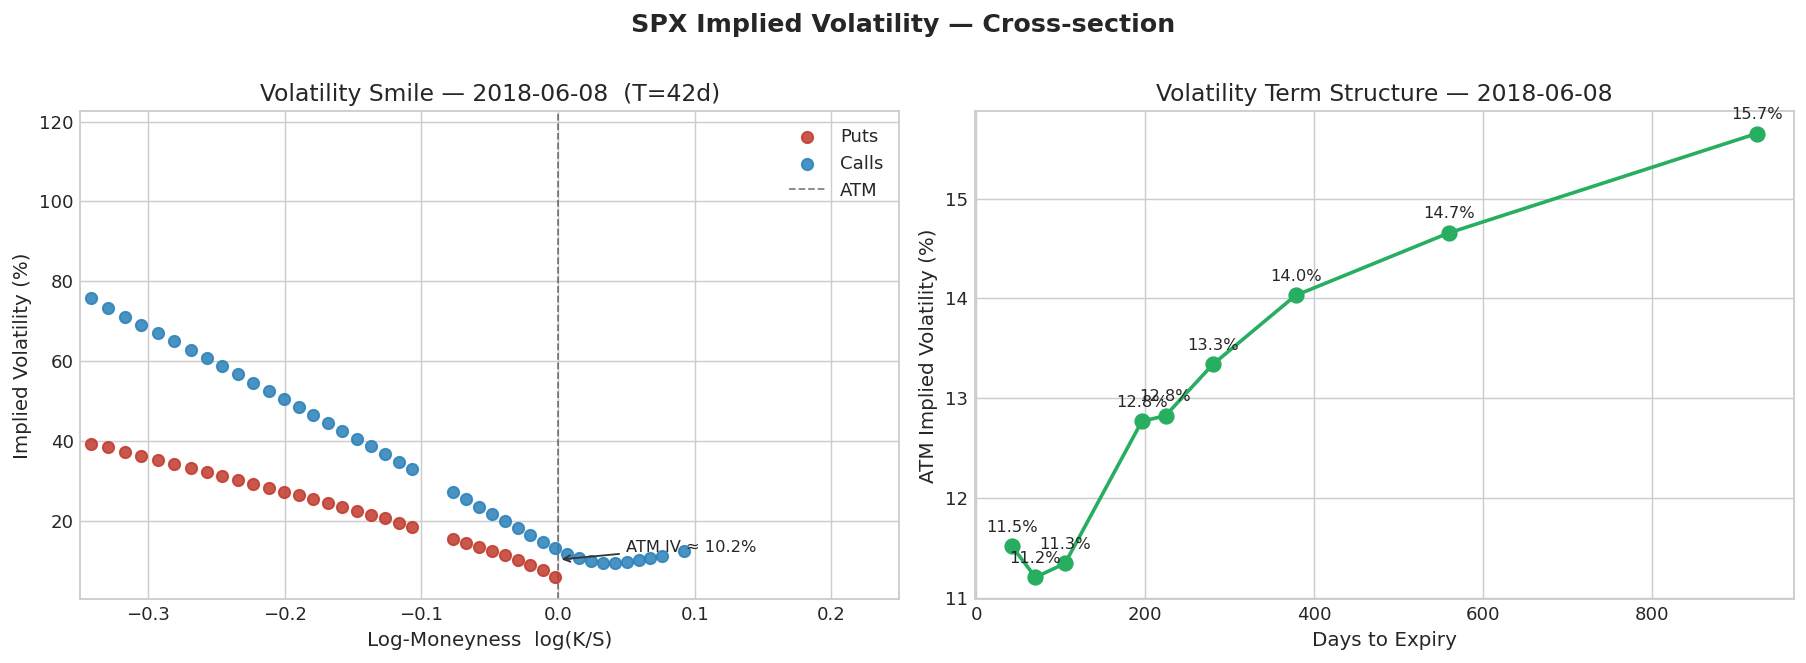

In [8]:
# ── Pick one representative date ──────────────────────────────────────────────
sample_date = pd.Timestamp('2018-06-08')   # change as needed
day_df = df[df['date'] == sample_date]

# Best expiry ~ TARGET_TENOR days
exp_options = day_df['exp_date'].unique()
best_exp    = exp_options[
    np.argmin(np.abs((pd.to_datetime(exp_options) - sample_date).days - TARGET_TENOR))
]
smile_df = day_df[day_df['exp_date'] == best_exp].sort_values('log_m')
T_actual = int((best_exp - sample_date).days)
print(f"Plotting smile for {sample_date.date()}  expiry={best_exp.date()}  T={T_actual}d")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Smile
ax = axes[0]
for opt_type, color, label in [('P','#c0392b','Puts'), ('C','#2980b9','Calls')]:
    sub = smile_df[smile_df['type'] == opt_type]
    ax.scatter(sub['log_m'], sub['iv']*100, color=color, s=40, alpha=0.85,
               label=label, zorder=3)
ax.axvline(0, color='#333', lw=1, ls='--', alpha=0.6, label='ATM')
atm_iv_val = smile_df[smile_df['log_m'].abs() < 0.01]['iv'].mean() * 100
ax.annotate(f'ATM IV ≈ {atm_iv_val:.1f}%', xy=(0, atm_iv_val),
            xytext=(0.05, atm_iv_val + 2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.set(xlabel='Log-Moneyness  log(K/S)', ylabel='Implied Volatility (%)',
       title=f'Volatility Smile — {sample_date.date()}  (T={T_actual}d)',
       xlim=(-0.35, 0.25))
ax.legend(fontsize=10)

# Right: Term structure of ATM IV
ts_rows = []
for exp in sorted(day_df['exp_date'].unique()):
    sub = day_df[(day_df['exp_date'] == exp) & (day_df['log_m'].abs() < 0.03)]
    if len(sub) > 0:
        ts_rows.append({'days': (exp - sample_date).days, 'atm_iv': sub['iv'].mean()*100})
ts = pd.DataFrame(ts_rows)
ax = axes[1]
ax.plot(ts['days'], ts['atm_iv'], 'o-', color='#27ae60', lw=2, ms=8)
for _, r in ts.iterrows():
    ax.annotate(f"{r['atm_iv']:.1f}%", (r['days'], r['atm_iv']),
                textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')
ax.set(xlabel='Days to Expiry', ylabel='ATM Implied Volatility (%)',
       title=f'Volatility Term Structure — {sample_date.date()}')

plt.suptitle('SPX Implied Volatility — Cross-section', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


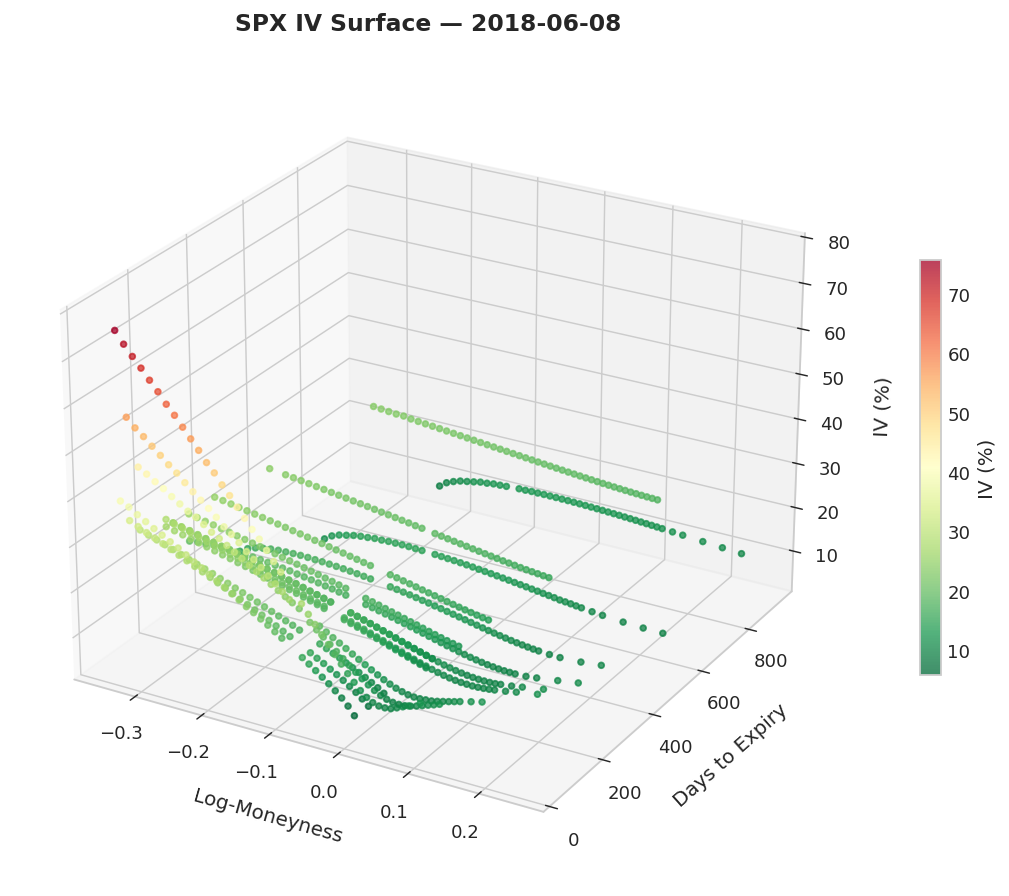

In [9]:
# ── 3-D volatility surface ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
surf_df = day_df[(day_df['log_m'] > -0.35) & (day_df['log_m'] < 0.25)]
sc = ax.scatter(surf_df['log_m'], surf_df['T']*365, surf_df['iv']*100,
                c=surf_df['iv']*100, cmap='RdYlGn_r', s=10, alpha=0.75)
ax.set_xlabel('Log-Moneyness', labelpad=8)
ax.set_ylabel('Days to Expiry', labelpad=8)
ax.set_zlabel('IV (%)', labelpad=8)
ax.set_title(f'SPX IV Surface — {sample_date.date()}', fontweight='bold', pad=12)
plt.colorbar(sc, ax=ax, shrink=0.5, label='IV (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


## 5 · Daily time-series: ATM IV (constant maturity), skew, convexity

### 5.1 The varying-tenor problem

A naive approach would select, each day, the expiry closest to the target tenor (30 days). This produces a **heterogeneous** $X_t$: the selected option may have 42 days to expiry one day and 20 days the next, with discrete jumps each time a new expiry becomes the nearest. Within a single expiry cycle the tenor drifts continuously downward, then jumps abruptly at each roll. Comparing a 42-day IV one day to a 20-day IV the next breaks the consistency of the regressor series $X_t$.



### 5.2 Solution: constant-maturity interpolation

We bracket the target tenor $\tau = 30$ days between the two available expiries $T_1 \leq \tau < T_2$ and interpolate **in variance** (linearly in $\sigma^2$, not in $\sigma$):

$$\sigma_{\tau}^2 = \frac{T_2 - \tau}{T_2 - T_1}\,\sigma_{T_1}^2 + \frac{\tau - T_1}{T_2 - T_1}\,\sigma_{T_2}^2$$

$$\sigma_{\tau} = \sqrt{\sigma_{\tau}^2}$$

Interpolation is performed in variance rather than volatility because variance is additive in time under Black-Scholes: $\sigma^2 T$ represents the expected integrated variance, and it is this quantity that scales linearly with $T$. This is exactly the methodology used by the **CBOE to compute the VIX**.

### 5.3 Extracted metrics

The same three metrics are computed for each of the two bracketing expiries and then interpolated separately:

$$\text{Skew}_t = \overline{\text{IV}}_{\text{put wing}} - \overline{\text{IV}}_{\text{call wing}}$$

$$\text{Convexity}_t = \frac{\overline{\text{IV}}_{\text{put wing}} + \overline{\text{IV}}_{\text{call wing}}}{2} - \text{ATM\_IV}_t$$

In [10]:
metrics = extract_daily_metrics(df, TARGET_TENOR, WING_LOW, WING_HIGH_PUT, WING_LOW_CALL, WING_HIGH)
metrics.head()

✓ Daily metrics: 253 trading days  (constant-maturity 30d interpolation)


,atm_iv,skew,convexity,iv_put_wing,iv_call_wing
date,,,,,
2017-06-08,0.085393,0.068379,0.046147,0.165730,0.097351
2017-06-09,0.083154,NaN,NaN,0.169154,NaN
2017-06-12,0.084561,0.074390,0.054408,0.176163,0.101773
2017-06-13,0.105945,0.068611,0.029695,0.169946,0.101334
2017-06-14,0.106155,0.064821,0.036631,0.175197,0.110375


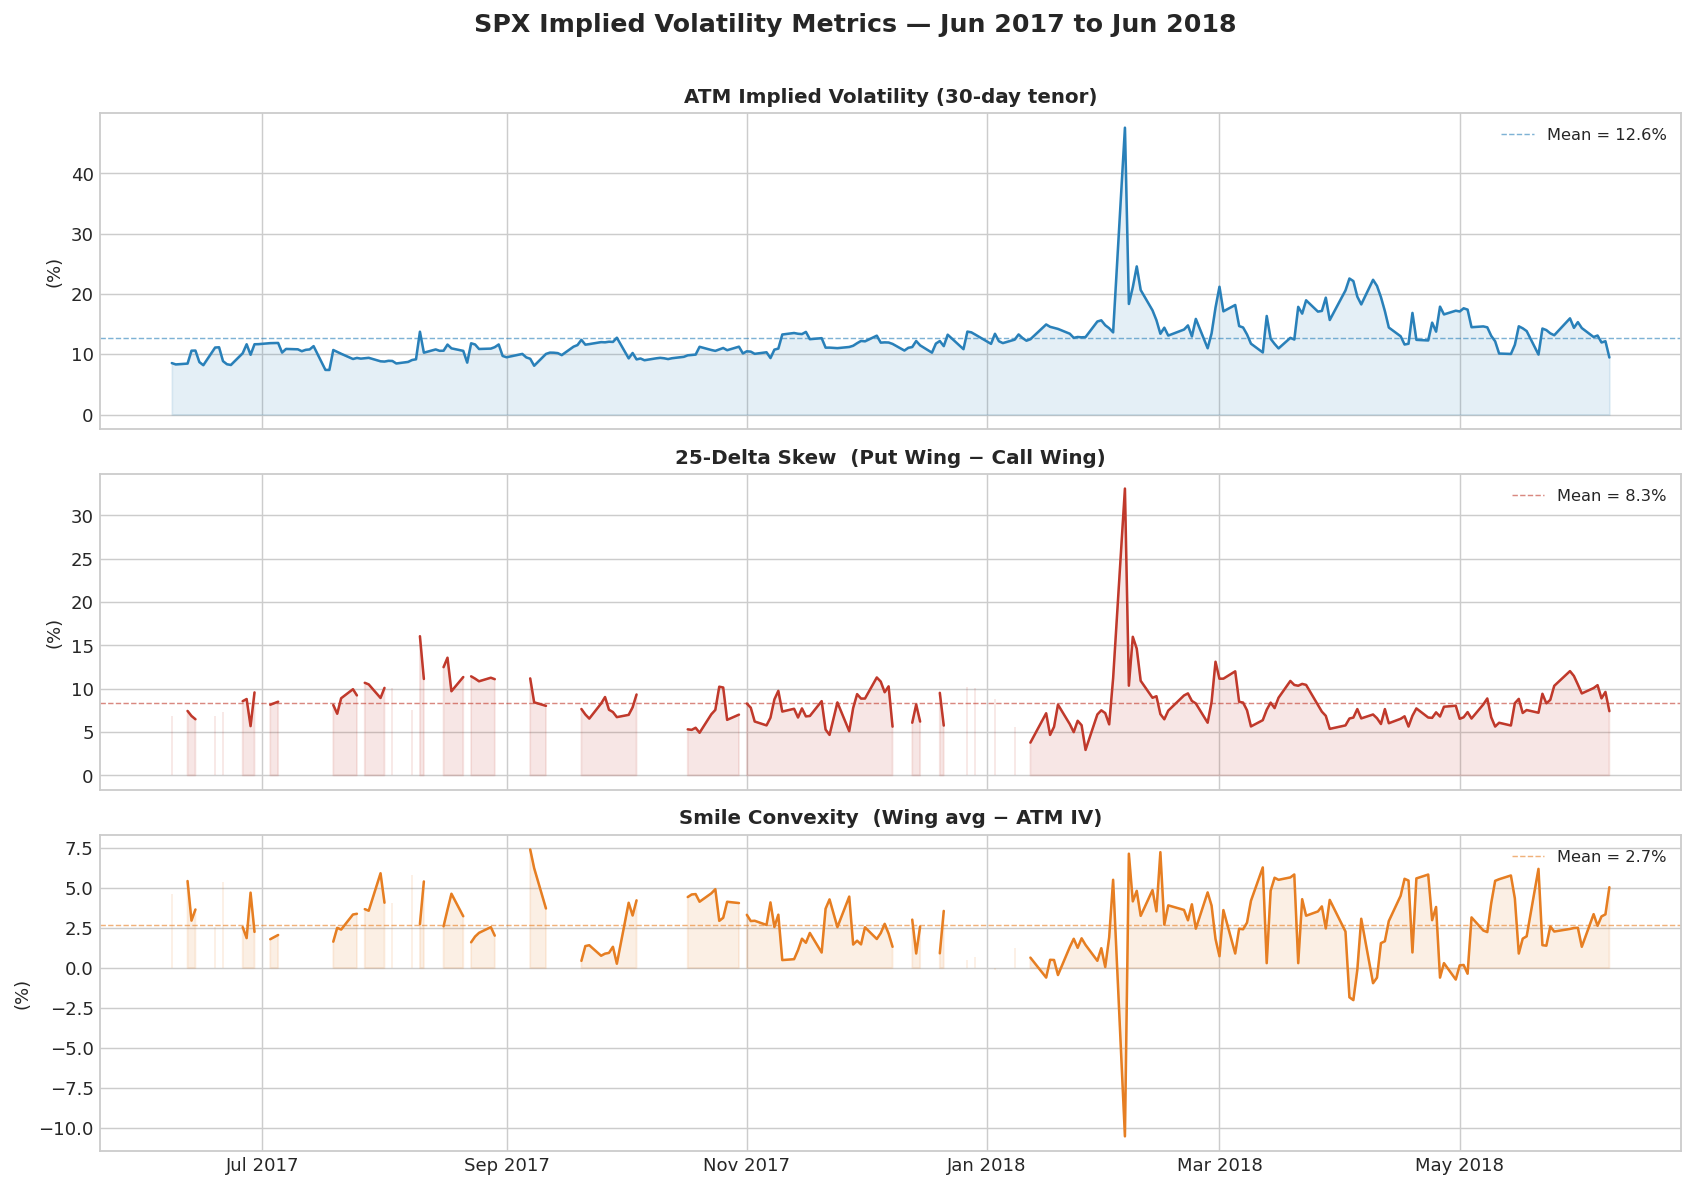

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['#2980b9', '#c0392b', '#e67e22']
titles = ['ATM Implied Volatility (30-day tenor)',
          '25-Delta Skew  (Put Wing − Call Wing)',
          'Smile Convexity  (Wing avg − ATM IV)']
cols   = ['atm_iv', 'skew', 'convexity']

for ax, col, color, title in zip(axes, cols, colors, titles):
    y = metrics[col] * 100
    ax.plot(metrics.index, y, color=color, lw=1.4)
    ax.fill_between(metrics.index, y, alpha=0.12, color=color)
    ax.axhline(y.mean(), color=color, lw=0.8, ls='--', alpha=0.6,
               label=f'Mean = {y.mean():.1f}%')
    ax.set_ylabel('(%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('SPX Implied Volatility Metrics — Jun 2017 to Jun 2018',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6 · Realized volatility & Variance Risk Premium

**Realized volatility** (historical) over a rolling 21-day window:

$$RV_t = \sqrt{252} \cdot \hat\sigma\left(r_{t-20},\ldots,r_{t}\right), \quad r_t = \ln\frac{S_t}{S_{t-1}}$$

**Forward realized volatility** (what we want to predict):

$$RV^{\text{fwd}}_t = \sqrt{252} \cdot \hat\sigma\left(r_{t+1},\ldots,r_{t+21}\right)$$

**Variance Risk Premium**:

$$\text{VRP}_t = IV_t - RV_t \quad (\text{typically positive → investors overpay for vol protection})$$


=== Variance Risk Premium ===
Mean VRP (IV − RV) : +1.60%
Mean VRP (IV − RV) : +1.60%
Std  VRP           :  6.59%
% positive (IV>RV) :  72.5%
Sample size        :  211 days


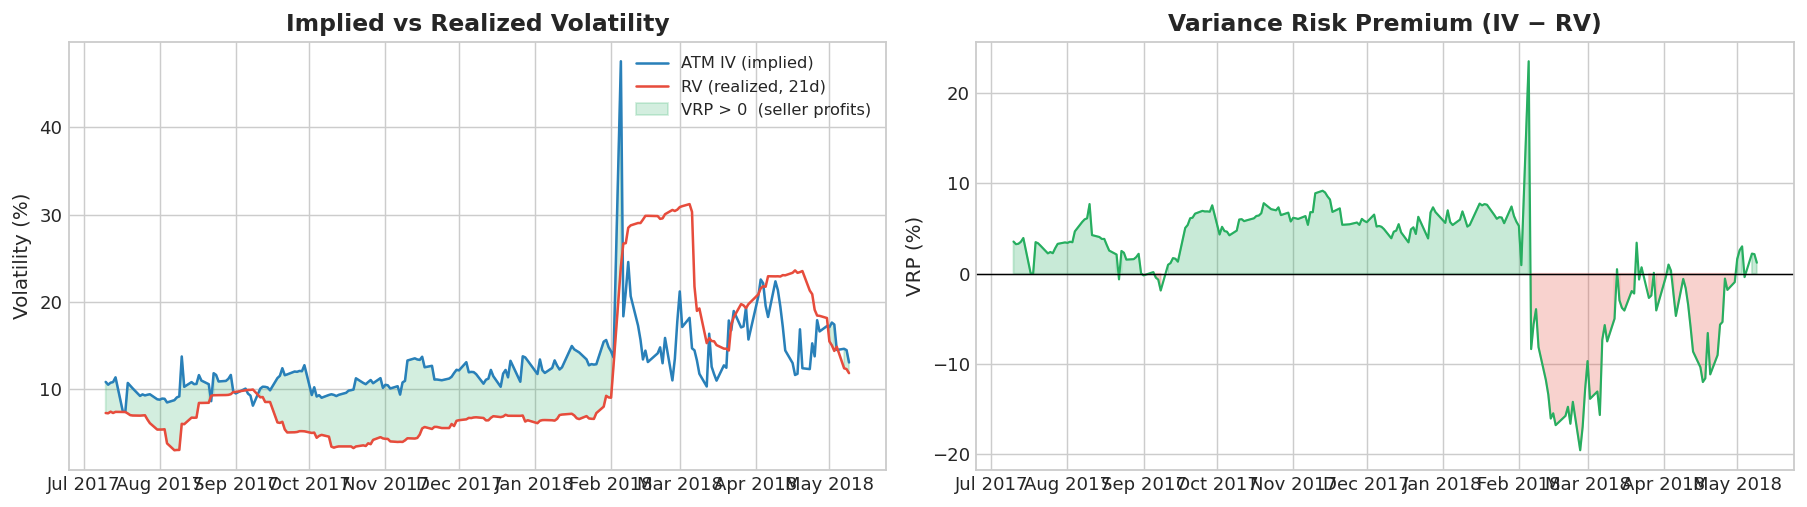

In [12]:
# ── Spot price from the dataset itself (put-call parity median per day) ────────
spot_ts = df.groupby('date')['spot'].median().sort_index()

# Add extra buffer around the sample for the rolling windows
log_ret = np.log(spot_ts / spot_ts.shift(1))

rv_past    = log_ret.rolling(RV_WINDOW).std() * np.sqrt(252)
rv_forward = log_ret.shift(-RV_WINDOW).rolling(RV_WINDOW).std() * np.sqrt(252)

# Merge into regression dataframe
reg = metrics.copy()
reg['rv_past']    = rv_past.reindex(reg.index)
reg['rv_forward'] = rv_forward.reindex(reg.index)
reg['vrp']        = reg['atm_iv'] - reg['rv_past']
reg = reg.dropna(subset=['atm_iv', 'rv_past', 'rv_forward'])

print("=== Variance Risk Premium ===")
print(f"Mean VRP (IV − RV) : {reg['vrp'].mean()*100:+.2f}%")
print(f"Mean VRP (IV − RV) : {reg['vrp'].mean()*100:+.2f}%")
print(f"Std  VRP           :  {reg['vrp'].std()*100:.2f}%")
print(f"% positive (IV>RV) :  {(reg['vrp']>0).mean()*100:.1f}%")
print(f"Sample size        :  {len(reg)} days")

# ── Plot IV vs RV ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(reg.index, reg['atm_iv']*100, color='#2980b9', lw=1.4, label='ATM IV (implied)')
ax.plot(reg.index, reg['rv_past']*100, color='#e74c3c', lw=1.4, label='RV (realized, 21d)')
ax.fill_between(reg.index, reg['atm_iv']*100, reg['rv_past']*100,
                where=reg['atm_iv'] > reg['rv_past'], alpha=0.2, color='#27ae60',
                label='VRP > 0  (seller profits)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Volatility (%)')
ax.set_title('Implied vs Realized Volatility', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(reg.index, reg['vrp']*100, color='#27ae60', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']>0, alpha=0.25, color='#27ae60')
ax.fill_between(reg.index, reg['vrp']*100, 0,
                where=reg['vrp']<=0, alpha=0.25, color='#e74c3c')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('VRP (%)')
ax.set_title('Variance Risk Premium (IV − RV)', fontweight='bold')

plt.tight_layout()
plt.show()


## 7 · Regression analysis

We implement OLS from scratch:

$$\hat\beta = (X'X)^{-1}X'y, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}, \qquad \widehat{\text{Var}}(\hat\beta) = s^2(X'X)^{-1}$$

**Dependent variable** $y_t = RV^{\text{fwd}}_t$: annualized realized volatility over the
21 trading days following day $t$:

$$RV^{\text{fwd}}_t = \sqrt{252}\cdot\hat\sigma(r_{t+1},\ldots,r_{t+21})$$

**Regressors**: ATM IV at constant 30-day maturity (VIX methodology), skew, convexity.

We estimate four nested models: M1 ⊂ M2 ⊂ M3, then M4 as the parsimonious specification.

In [13]:
# Diagnostique
print(metrics[['atm_iv','skew','convexity']].isna().sum())
print(f"Jours avec atm_iv : {metrics['atm_iv'].notna().sum()}")
print(f"Jours avec skew   : {metrics['skew'].notna().sum()}")
print(f"Jours avec conv   : {metrics['convexity'].notna().sum()}")

# Combien d'options n'ont pas de F_impl ?
print(f"Options sans F_impl : {df['F_impl'].isna().sum():,} / {len(df):,}")
print(f"Expiries affectées  : {df[df['F_impl'].isna()]['exp_date'].nunique()}")

metrics = extract_daily_metrics(df, TARGET_TENOR, WING_LOW, WING_HIGH_PUT, WING_LOW_CALL, WING_HIGH)
print(metrics[['atm_iv','skew','convexity']].isna().sum())

atm_iv        0
skew         57
convexity    57
dtype: int64
Jours avec atm_iv : 253
Jours avec skew   : 196
Jours avec conv   : 196
Options sans F_impl : 0 / 263,064
Expiries affectées  : 0
✓ Daily metrics: 253 trading days  (constant-maturity 30d interpolation)
atm_iv        0
skew         57
convexity    57
dtype: int64


In [14]:
y = reg['rv_forward']

### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

In [15]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$


In [16]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$

In [17]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 4

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Convexity}_t + \varepsilon_t$$

In [18]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Convexity")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'convexity']])
reg_table(r4, ['Const', 'ATM_IV', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                    -0.0049    0.0300   -0.162    0.8714 
ATM_IV                    0.8591    0.1720    4.996    0.0000 ***
Convexity                 0.5760    0.3386    1.701    0.0909 
──────────────────────────────────────────────────────────────
R²                        0.1456
Adj. R²                   0.1349
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [19]:
data  = reg[['atm_iv', 'convexity', 'rv_forward']].dropna()
y_m4  = data['rv_forward'].values
X_m4  = sm.add_constant(data[['atm_iv', 'convexity']].values)

res_ols = sm.OLS(y_m4, X_m4).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m4)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=54.294  p=0.0000  reject normality
Durbin-Watson   : 0.1648            autocorrelation present
White           : stat=19.202  p=0.0018  reject homoscedasticity
Breusch-Godfrey : stat=148.239  p=  0.0000  reject no autocorrelation


In [20]:
# Build the restricted sample once — rows where all features are non-NaN
reg_full = reg[['rv_forward', 'atm_iv', 'skew', 'convexity']].dropna()

y_r = reg_full['rv_forward']

print("═"*62)
print("MODEL 1 (restricted) — RV_fwd ~ ATM_IV  [N=163 sample]")
print("═"*62)
r1_r = ols(y_r, reg_full[['atm_iv']])
reg_table(r1_r, ['Const', 'ATM_IV'])

print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2_r = ols(y_r, reg_full[['atm_iv', 'skew']])
reg_table(r2_r, ['Const', 'ATM_IV', 'Skew'])

print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3_r = ols(y_r, reg_full[['atm_iv', 'skew', 'convexity']])
reg_table(r3_r, ['Const', 'ATM_IV', 'Skew', 'Convexity'])

print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Convexity")
print("═"*62)
r4_r = ols(y_r, reg_full[['atm_iv', 'convexity']])
reg_table(r4_r, ['Const', 'ATM_IV', 'Convexity'])

══════════════════════════════════════════════════════════════
MODEL 1 (restricted) — RV_fwd ~ ATM_IV  [N=163 sample]
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0335    0.0200    1.679    0.0951 
ATM_IV                    0.6876    0.1401    4.907    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1301
Adj. R²                   0.1247
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001

══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Varia

## 8 · CLRM diagnostics & Newey-West correction

Standard OLS assumptions tested on Model 4 residuals:

| Test | $H_0$ | Statistic | p-value | Conclusion |
|---|---|---|---|---|
| **Jarque-Bera** | Normality | — | — | — |
| **Durbin-Watson** | No AR(1) autocorr. | — | — | — |
| **White** | Homoscedasticity | — | — | — |
| **Breusch-Godfrey (p=21)** | No AR(21) autocorr. | — | — | — |

**Key violation: autocorrelation** — structural consequence of the 21-day overlapping windows.
$y_t$ and $y_{t+1}$ share 20 days of returns → $\hat\rho_1 \approx 0.875$ by construction.

**Key violation: heteroscedasticity** — residual variance spikes during stress periods (Feb 2018).

OLS $\hat\beta$ remains **unbiased and consistent** — only standard errors are invalid.

### Newey-West (HAC) correction

Corrects simultaneously for autocorrelation and heteroscedasticity:

$$\widehat{\text{Var}}_{NW}(\hat\beta) = (X'X)^{-1}\hat\Omega_{NW}(X'X)^{-1}$$

Number of lags = 20 (= RV window $-$ 1), following the overlapping structure of $y_t$.


In [21]:
res_nw  = sm.OLS(y_m4, X_m4).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

# Vérification : les coefs doivent être identiques à r4
print("Coefs statsmodels :", res_ols.params)
print("Coefs from scratch:", r4['beta'])
print()
print(res_nw.summary())

Coefs statsmodels : [-0.00487038  0.85913351  0.57601194]
Coefs from scratch: [-0.00487038  0.85913351  0.57601194]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     4.321
Date:                Thu, 21 May 2026   Prob (F-statistic):             0.0149
Time:                        14:12:36   Log-Likelihood:                 192.23
No. Observations:                 163   AIC:                            -378.5
Df Residuals:                     160   BIC:                            -369.2
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------

### Extension — adding the VIX as regressor

The CBOE VIX is the market benchmark for 30-day implied volatility.
We test whether the VIX adds predictive power **beyond** our surface-derived ATM IV,
or whether our constant-maturity interpolation already captures the same information.

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Conv}_t + \beta_3 \cdot VIX_t + \varepsilon_t$$

If $\beta_3$ is not significant, our ATM IV subsumes the VIX — confirming that the
VIX interpolation methodology correctly extracts the same signal from the surface.

In [22]:
# Import VIc index from yahoofinance 

vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end = "2018-06-08")
Vix_close = hist["Close"]

In [23]:
reg_base = reg.copy()   # protect reg before adding VIX
Vix_close.index = Vix_close.index.tz_localize(None)
reg = reg_base.join(Vix_close.rename("vix"), how="left")
reg


,atm_iv,skew,convexity,iv_put_wing,iv_call_wing,rv_past,rv_forward,vrp,vix
date,,,,,,,,,
2017-07-10,0.108259,NaN,NaN,0.170180,NaN,0.072598,0.030226,0.035661,11.11
2017-07-11,0.105050,NaN,NaN,0.177707,NaN,0.072306,0.030257,0.032744,10.89
2017-07-12,0.107376,NaN,NaN,0.168411,NaN,0.074135,0.060221,0.033242,10.30
2017-07-13,0.108068,NaN,NaN,0.164620,NaN,0.072657,0.059797,0.035411,9.90
2017-07-14,0.113509,NaN,NaN,0.167575,NaN,0.073915,0.067324,0.039593,9.51
...,...,...,...,...,...,...,...,...,...
2018-05-03,0.174104,0.073053,-0.003481,0.207149,0.134095,0.143787,0.100371,0.030317,15.90
2018-05-04,0.144902,0.065665,0.031692,0.209427,0.143762,0.148595,0.093206,-0.003693,14.77
2018-05-07,0.146228,0.081956,0.023497,0.210702,0.128746,0.123920,0.095326,0.022307,14.75


In [24]:
print("═"*62)
print("MODEL 5 — Baseline: RV_fwd ~ ATM_IV + VIX")
print("═"*62)
r1 = ols(y, reg[['atm_iv', "vix"]])
reg_table(r1, ['Const', 'ATM_IV', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 5 — Baseline: RV_fwd ~ ATM_IV + VIX
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0084    0.0169    0.496    0.6203 
ATM_IV                    0.4290    0.2133    2.011    0.0456 *
VIX                       0.0039    0.0017    2.261    0.0248 *
──────────────────────────────────────────────────────────────
R²                        0.1869
Adj. R²                   0.1791
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [25]:
print("\n" + "═"*62)
print("MODEL 6 — RV_fwd ~ ATM_IV + Skew + VIX")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew' , "vix"]])
reg_table(r2, ['Const', 'ATM_IV', 'Skew', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 6 — RV_fwd ~ ATM_IV + Skew + VIX
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0568    0.0207    2.744    0.0068 **
ATM_IV                    0.3656    0.2276    1.607    0.1101 
Skew                     -0.7502    0.2168   -3.461    0.0007 ***
VIX                       0.0057    0.0018    3.197    0.0017 **
──────────────────────────────────────────────────────────────
R²                        0.2293
Adj. R²                   0.2148
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [26]:
print("\n" + "═"*62)
print("MODEL 7 — RV_fwd ~ ATM_IV + Skew + Convexity + VIX")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity', "vix"]])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 7 — RV_fwd ~ ATM_IV + Skew + Convexity + VIX
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                   -0.3553    0.5368   -0.662    0.5091 
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX                       0.0102    0.0035    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [27]:
print("\n" + "═"*62)
print("MODEL 8 — RV_fwd ~ ATM_IV + Convexity + VIX")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'convexity', "vix"]])
reg_table(r4, ['Const', 'ATM_IV', 'Convexity', "VIX"])


══════════════════════════════════════════════════════════════
MODEL 8 — RV_fwd ~ ATM_IV + Convexity + VIX
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0844    0.0450    1.876    0.0625 
ATM_IV                   -0.5254    0.5531   -0.950    0.3436 
Convexity                -0.9092    0.6556   -1.387    0.1674 
VIX                       0.0096    0.0036    2.629    0.0094 **
──────────────────────────────────────────────────────────────
R²                        0.1812
Adj. R²                   0.1657
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [28]:
data  = reg[['atm_iv', 'convexity', 'rv_forward' , "vix"]].dropna()
y_m4  = data['rv_forward'].values
X_m4  = sm.add_constant(data[['atm_iv', 'convexity', "vix"]].values)

res_ols = sm.OLS(y_m4, X_m4).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m4)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=69.511  p=0.0000  reject normality
Durbin-Watson   : 0.1573            autocorrelation present
White           : stat=27.571  p=0.0011  reject homoscedasticity
Breusch-Godfrey : stat=148.702  p=  0.0000  reject no autocorrelation


In [29]:
res_nw  = sm.OLS(y_m4, X_m4).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

# Vérification : les coefs doivent être identiques à r4
print("Coefs statsmodels :", res_ols.params)
print("Coefs from scratch:", r4['beta'])
print()
print(res_nw.summary())

Coefs statsmodels : [ 0.08438735 -0.52539326 -0.90918511  0.0095667 ]
Coefs from scratch: [ 0.08438735 -0.52539326 -0.90918511  0.0095667 ]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     5.788
Date:                Thu, 21 May 2026   Prob (F-statistic):           0.000882
Time:                        14:12:38   Log-Likelihood:                 195.70
No. Observations:                 163   AIC:                            -383.4
Df Residuals:                     159   BIC:                            -371.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025   

## 9 · Fixed Effects & Random Effects — IV Surface Panel

### 9.1 Motivation

A pooled OLS mixing all 22 expiries confounds two effects:
- The **causal** relationship: when IV rises, does future RV rise?
- The **term structure**: long-dated options have structurally higher IV

We verify this with an **F-test on entity fixed effects**:

$$F = \frac{(SSR_{\text{pooled}} - SSR_{\text{FE}})/(N-1)}{SSR_{\text{FE}}/(NT-N-K)} \sim F(N-1,\ NT-N-K)$$

### 9.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_t = \alpha_i + \beta_1 IV_{it} + \beta_2 \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs the average IV level of each expiry. Identification from within-expiry deviations:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \qquad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

### 9.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0,\sigma^2_\alpha)$ uncorrelated with regressors.
Quasi-demeaning parameter:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T\cdot\sigma^2_\alpha}}$$

### 9.4 Hausman test

$$H_0: \alpha_i \perp X_{it} \implies \text{RE consistent}$$

$$H = (\hat\beta_{FE}-\hat\beta_{RE})^\top[\text{Var}(\hat\beta_{FE})-\text{Var}(\hat\beta_{RE})]^{-1}(\hat\beta_{FE}-\hat\beta_{RE}) \sim \chi^2(K)$$

Reject $H_0$ → entity effects correlated with regressors → **FE is the consistent estimator**.

In [30]:
from linearmodels.panel import PanelOLS, RandomEffects

# ── Panel construction ─────────────────────────────────────────────────────────
panel_surf = build_surface_panel(df, reg_base,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)
x_cols = ['atm_iv', 'skew']
print(f"Panel: {len(panel_surf)} obs  |  {panel_surf['expiry'].nunique()} expiries  |  {panel_surf['date'].nunique()} dates")

# ── F-test: are entity fixed effects significant? ──────────────────────────────
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
fe_surf  = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat   = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
            (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p      = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f"\nF-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {'Significant ✓' if F_p < 0.05 else 'Not significant'}")

# ── Fixed Effects & Random Effects (linearmodels) ──────────────────────────────
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
re_lm = RandomEffects(y_pan, X_pan).fit()

print('\n' + '═'*62)
print('FIXED EFFECTS'); print(fe_lm.summary.tables[1])
print('\n' + '═'*62)
print('RANDOM EFFECTS'); print(re_lm.summary.tables[1])

Panel: 2240 obs  |  21 expiries  |  211 dates

F-test entity effects : F = 14.338,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
atm_iv         0.5891     0.0916     6.4323     0.0000      0.4095      0.7688
skew           1.2989     0.2611     4.9749     0.0000      0.7869      1.8109

══════════════════════════════════════════════════════════════
RANDOM EFFECTS
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0013     0.0135     0.0993     0.9209     -0.0252      0.0279
atm_iv         0.793

### 9.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad \Rightarrow \text{RE consistent and efficient}$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- **Reject** $H_0$: expiry effects correlated with regressors → only **FE** is consistent
- **Cannot reject**: RE is consistent and more efficient → **prefer RE**

In [31]:
fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
re_lm = RandomEffects(y_pan, X_pan).fit()

b_fe   = fe_lm.params.values
b_re   = re_lm.params[x_cols].values
V_fe   = fe_lm.cov.values
V_re   = re_lm.cov.loc[x_cols, x_cols].values
diff   = b_fe - b_re
H      = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p      = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f"Hausman : stat={H:.4f}  p={p:.4f}")

Hausman : stat=53.4253  p=0.0000


# ARMA
(for a single TS -> atm_iv)

In [32]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3225
p-value: 0.0139


p<0.05 now -> it is stationnary

Best ARIMA order: (p=3, d=0, q=0) with AIC=-886.45


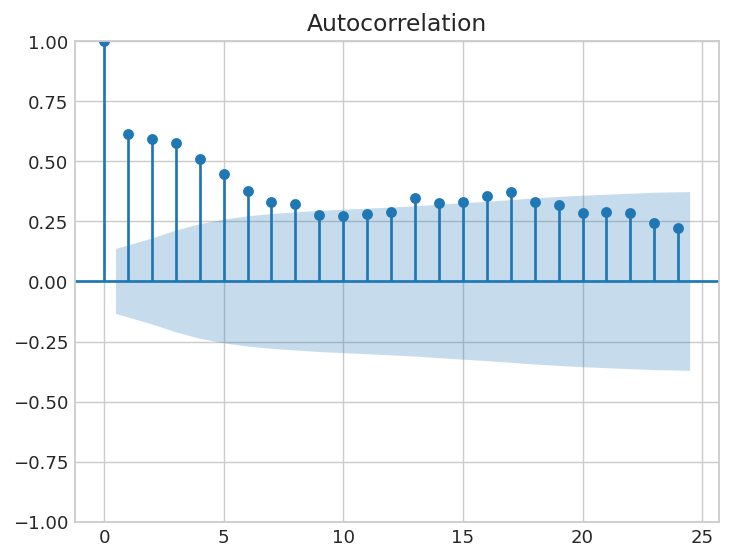

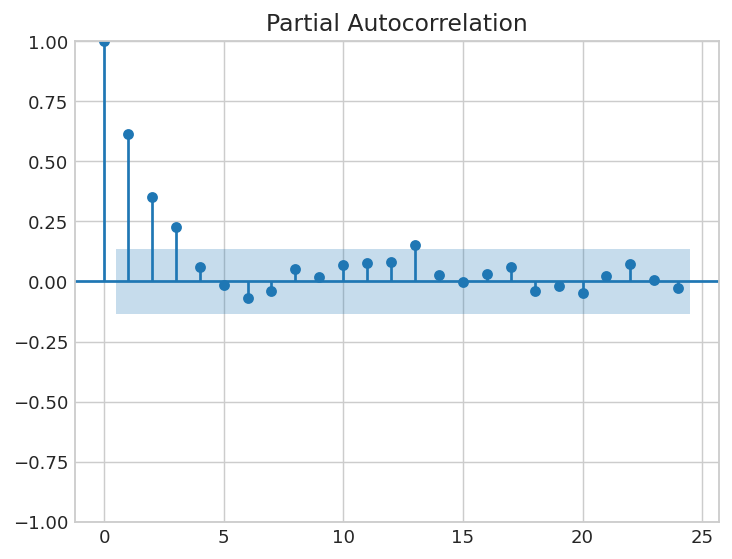

In [49]:
# identfy p and q

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(reg['atm_iv'].dropna())  # gives p
plot_pacf(reg['atm_iv'].dropna())   # gives q

from statsmodels.tsa.arima.model import ARIMA
import itertools

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model = ARIMA(reg['atm_iv'].dropna(), order=(p,0,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=0, q={best_q}) with AIC={best_aic:.2f}")

In [55]:
model = ARIMA(reg['atm_iv'].dropna(), order=(best_p,0,best_q)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                 atm_iv   No. Observations:                  211
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 448.226
Date:                Thu, 21 May 2026   AIC                           -886.451
Time:                        17:56:23   BIC                           -869.692
Sample:                             0   HQIC                          -879.677
                                - 211                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1282      0.020      6.425      0.000       0.089       0.167
ar.L1          0.3151      0.041      7.624      0.000       0.234       0.396
ar.L2          0.2600      0.081      3.225      0.0

Kurtosis = 88.21 → extreme fat tails (normal distribution has kurtosis = 3)

JB huge -> residuals non gaussian

heteroskedasticity : we reject it, the variance is not constant

In [56]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=10)

,lb_stat,lb_pvalue
1,0.034929,0.851744
2,0.094999,0.953611
3,0.115030,0.989975
4,1.523140,0.822535
5,1.640103,0.896358
6,2.156801,0.904727
7,3.115010,0.874163
8,3.121464,0.926505
9,4.154511,0.900952
10,4.915395,0.896758


p-value > 0.05, residuals are WN

Recap ARMA : for now just did with atm_iv, test with vix or skew or convexity ?

# VAR - first case

with atm_iv, skew and convexity (and vix ?)

In [57]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3225
p-value: 0.0139


In [58]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['skew'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.2698
p-value: 0.0005


In [59]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['convexity'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.5923
p-value: 0.0001


The three are stationnary 

In [74]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'atm_iv'   : reg['atm_iv'],   # ok stat
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity']         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

             atm_iv      skew  convexity
atm_iv     1.000000  0.467811  -0.586474
skew       0.467811  1.000000  -0.226771
convexity -0.586474 -0.226771   1.000000

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 21, May, 2026
Time:                     18:53:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.5346
Nobs:                     161.000    HQIC:                  -23.7733
Log likelihood:           1262.54    FPE:                4.02329e-11
AIC:                     -23.9365    Det(Omega_mle):     3.54104e-11
--------------------------------------------------------------------
Results for equation atm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.027113         0.013631            

Remark : multicollinearity -> look at the covariance matrix, it is ok

Looking at the p-values :

for constant, it si closed to 0.05 so borderline : so marginally significant 

significant terms : L1 atm_iv and L2 atm_iv -> Yesterday's and two-days-ago's volatility impacts  today's vol. If vol was high yesterday, it wants to stay high today.
A high convexity yesterday ->  atm_iv higher today.
high skew two days ago -> atm_iv lower today

non significant terms : L1 skew and l2 conv

In [62]:
# granger causality tests
print(results.test_causality('atm_iv', ['skew', 'convexity'], kind='f'))

# Does ATM_IV Granger-cause skew ?
print(results.test_causality('skew', ['atm_iv'], kind='f'))

# Does ATM_IV Granger-cause convexity ?
print(results.test_causality('convexity', ['atm_iv'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['skew', 'convexity'] do not Granger-cause atm_iv: reject at 5% significance level. Test statistic: 6.594, critical value: 2.391>, p-value: 0.000>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: atm_iv does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 0.354, critical value: 3.015>, p-value: 0.702>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: atm_iv does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 0.082, critical value: 3.015>, p-value: 0.921>


first test : \
Result : reject Ho at 5%\
p val : 0\
Analysis : we reject the null that they don't cause anything -> it means they impact atm_iv

2nd test : \
Result : reject H   at 5% \
p val : 0.702 \
Analysis : past atm_iv tells nothing about present skew

3rd test : \
Result : reject H0 at 5% \
p val : 0.921 \
Analysis ; past atm_iv tells nothing about present conv

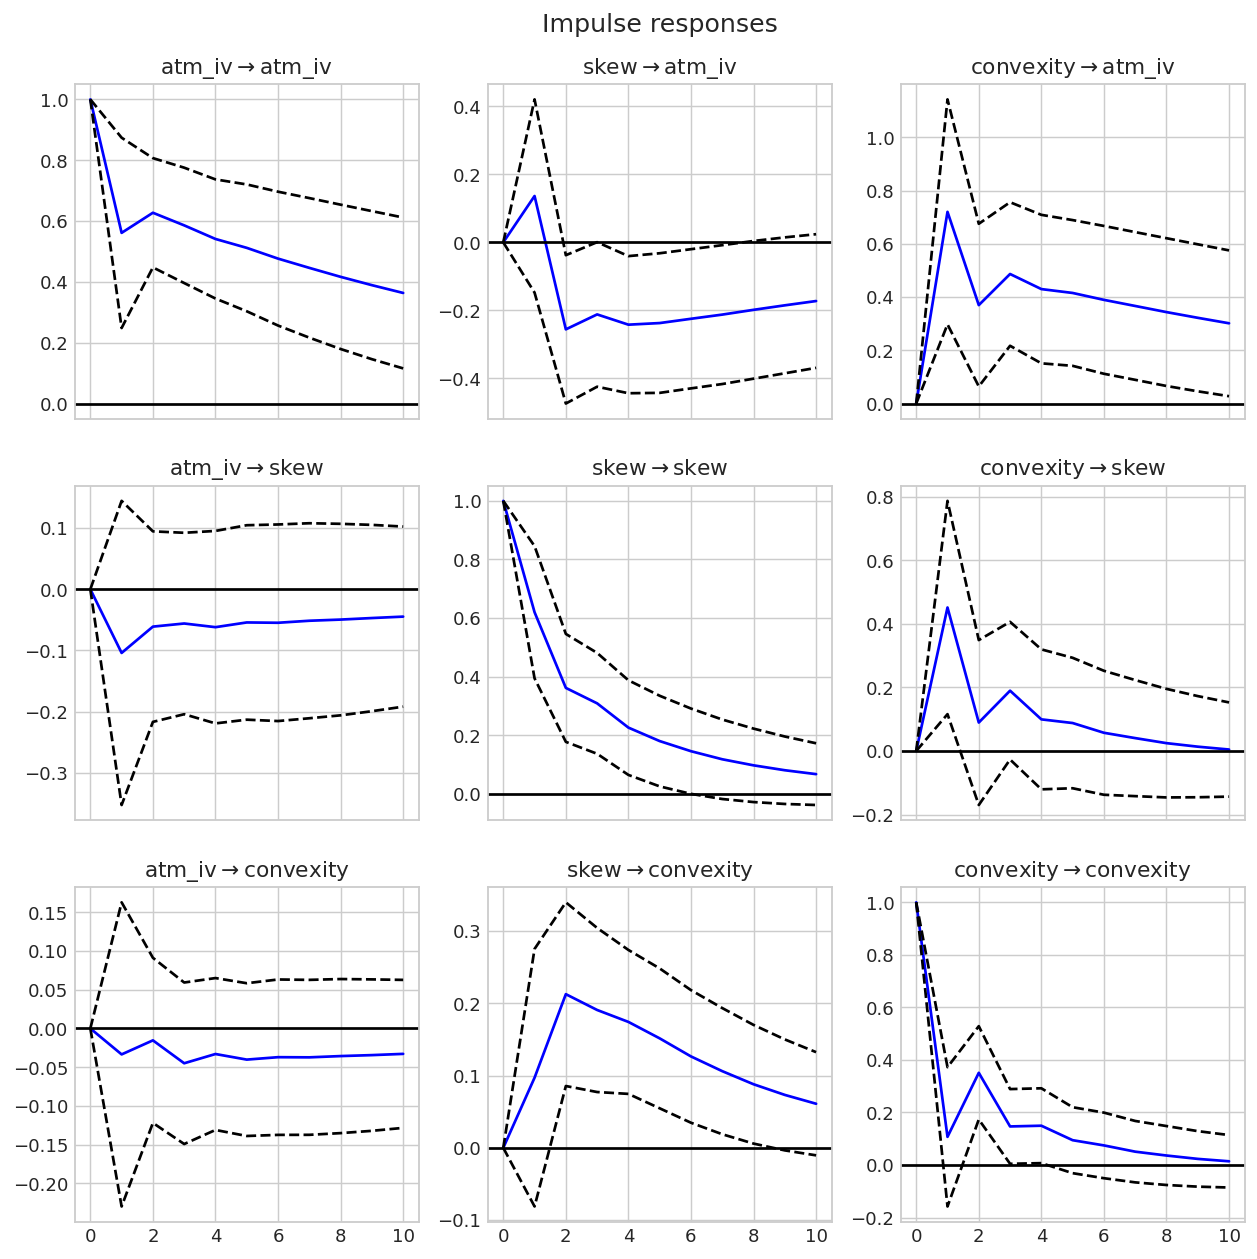

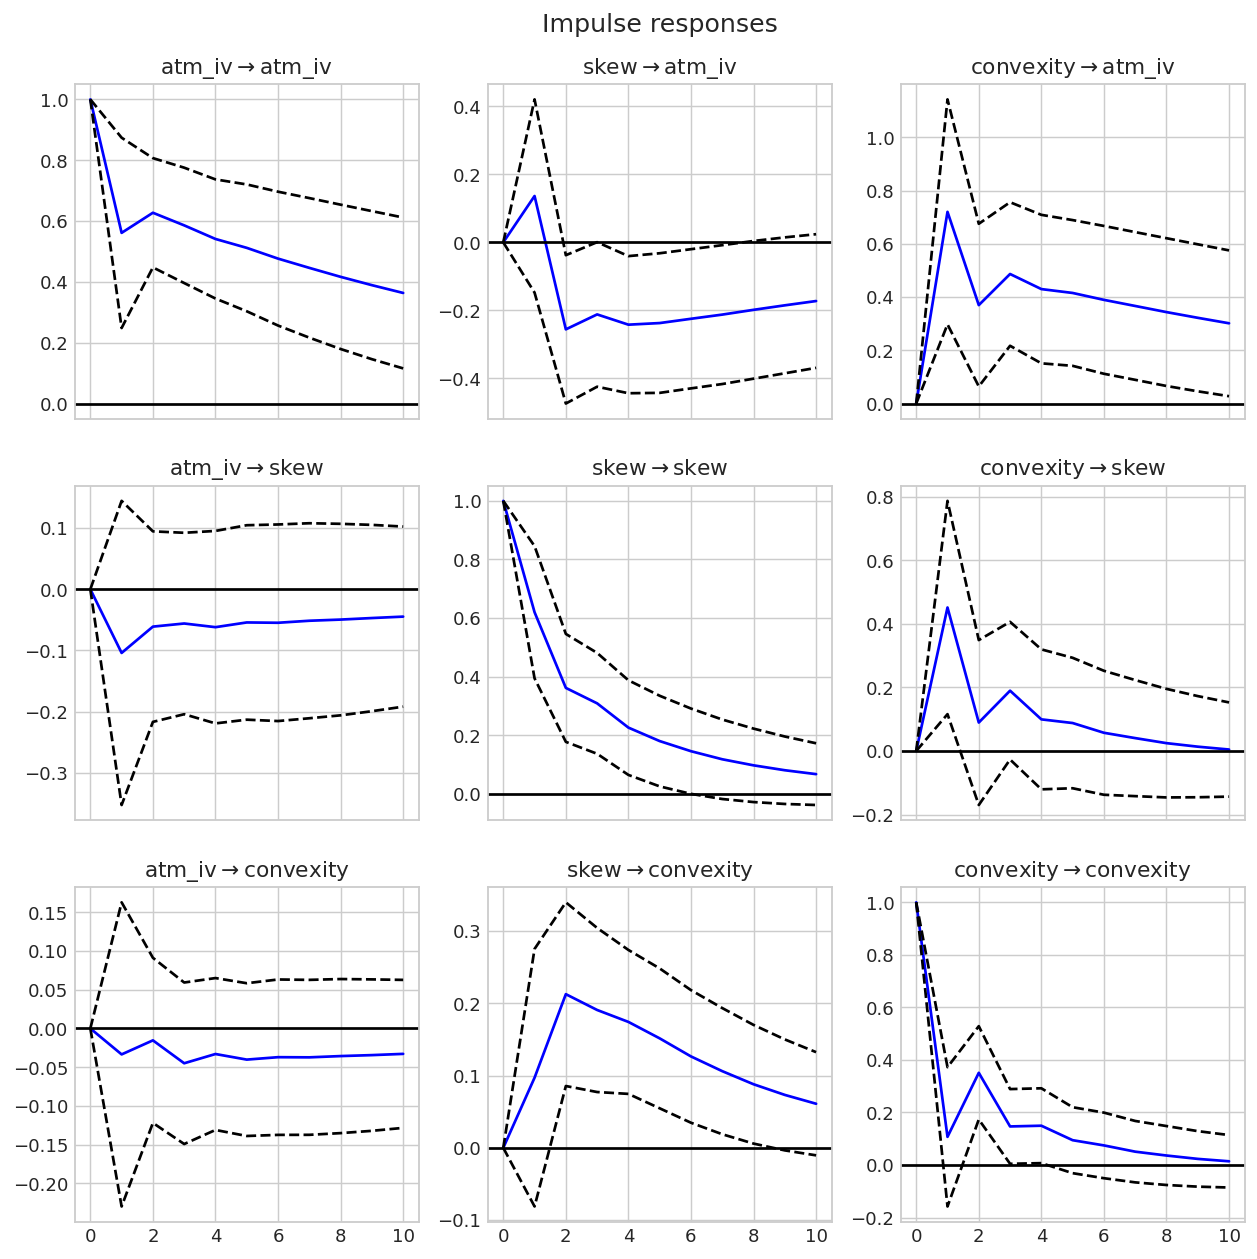

In [63]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

black lines -> confidence interval

read the IR : \
on the rows : variable that receive the shock \
on the columns : varaibel that responds \
example on the bottom left : how atm_iv responds to conv shock

# VAR - second case

VAR with atm_iv, skew, convexity and SP500 daily returns

In [64]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.log(spot_ts / spot_ts.shift(1)).dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -6.4767
p-value: 0.0000


In [75]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'atm_iv'   : reg['atm_iv'],   # stat already
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity'],       # ok stat
    'ret'       : np.log(spot_ts / spot_ts.shift(1))         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

             atm_iv      skew  convexity       ret
atm_iv     1.000000  0.467811  -0.586474 -0.380470
skew       0.467811  1.000000  -0.226771 -0.525155
convexity -0.586474 -0.226771   1.000000  0.202838
ret       -0.380470 -0.525155   0.202838  1.000000

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 21, May, 2026
Time:                     18:55:35
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -33.3370
Nobs:                     161.000    HQIC:                  -33.7463
Log likelihood:           1861.30    FPE:                1.67062e-15
AIC:                     -34.0260    Det(Omega_mle):     1.34396e-15
--------------------------------------------------------------------
Results for equation atm_iv
                  coefficient       std. error           t-stat            prob
-----------------------------------------------

Remark : multicollinearity -> look at the covariance matrix, it is ok

significant terms : L2 skew ; L2 atm_iv ; L1 ret ; const

non significant terms : L1 atm_iv ; L1.skew ; L1.conv ; L2.conv ; L2.ret

border : no border 

L1.ret : negative coeff and p-val 0.001 -> leverage effect (the SP 500 goes down today (-ret), implied volatility jumps up tomorrow ($+\text{atm\_iv}$)

First model : L1 atm_iv highly signif, 2nd model no, and L2 atm_iv becomes signif

Adding SP500 returns, the model is better, constant decreased, and AIC improved

In [70]:
print(results.test_causality('skew', ['ret'], kind='f'))
print(results.test_causality('atm_iv', ['ret'], kind='f'))
print(results.test_causality('convexity', ['ret'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 2.623, critical value: 3.011>, p-value: 0.073>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause atm_iv: reject at 5% significance level. Test statistic: 5.213, critical value: 3.011>, p-value: 0.006>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause convexity: reject at 5% significance level. Test statistic: 3.686, critical value: 3.011>, p-value: 0.026>


first test : \
fail to reject H0, but returns can have a small impact on skew

second test : \
reject H0, ret has a strong impact on atm_iv

third test : \
reject H0, p value border

### Model Comparison: 

coefficients and p-values before and after adding S&P 500 daily returns (`ret`). 

Statistically significant variables ($p < 0.05$) are highlighted in **bold**.*

| Variable | Model 1 (Surface Only) <br> Coeff (p-value) | Model 2 (With S&P 500) <br> Coeff (p-value) | 
| :--- | :---: | :---: | 
| **`const`** | **0.0271 (0.047)** | **0.0395 (0.008)** | 
| **`L1.atm_iv`** | **0.5612 (0.000)** | 0.2295 (0.218) | 
| **`L1.skew`** | 0.1363 (0.347) | 0.0112 (0.939) | 
| **`L1.convexity`**| **0.7199 (0.001)** | 0.3589 (0.132) | 
| **`L1.ret`** | *N/A* | **-1.2249 (0.001)** | 
| **`L2.atm_iv`** | **0.3507 (0.026)** | **0.6530 (0.000)** | 
| **`L2.skew`** | **-0.4866 (0.000)**| **-0.4395 (0.002)**| 
| **`L2.convexity`**| -0.1730 (0.396) | 0.1156 (0.595) | 
| **`L2.ret`** | *N/A* | -0.0012 (0.997) | 

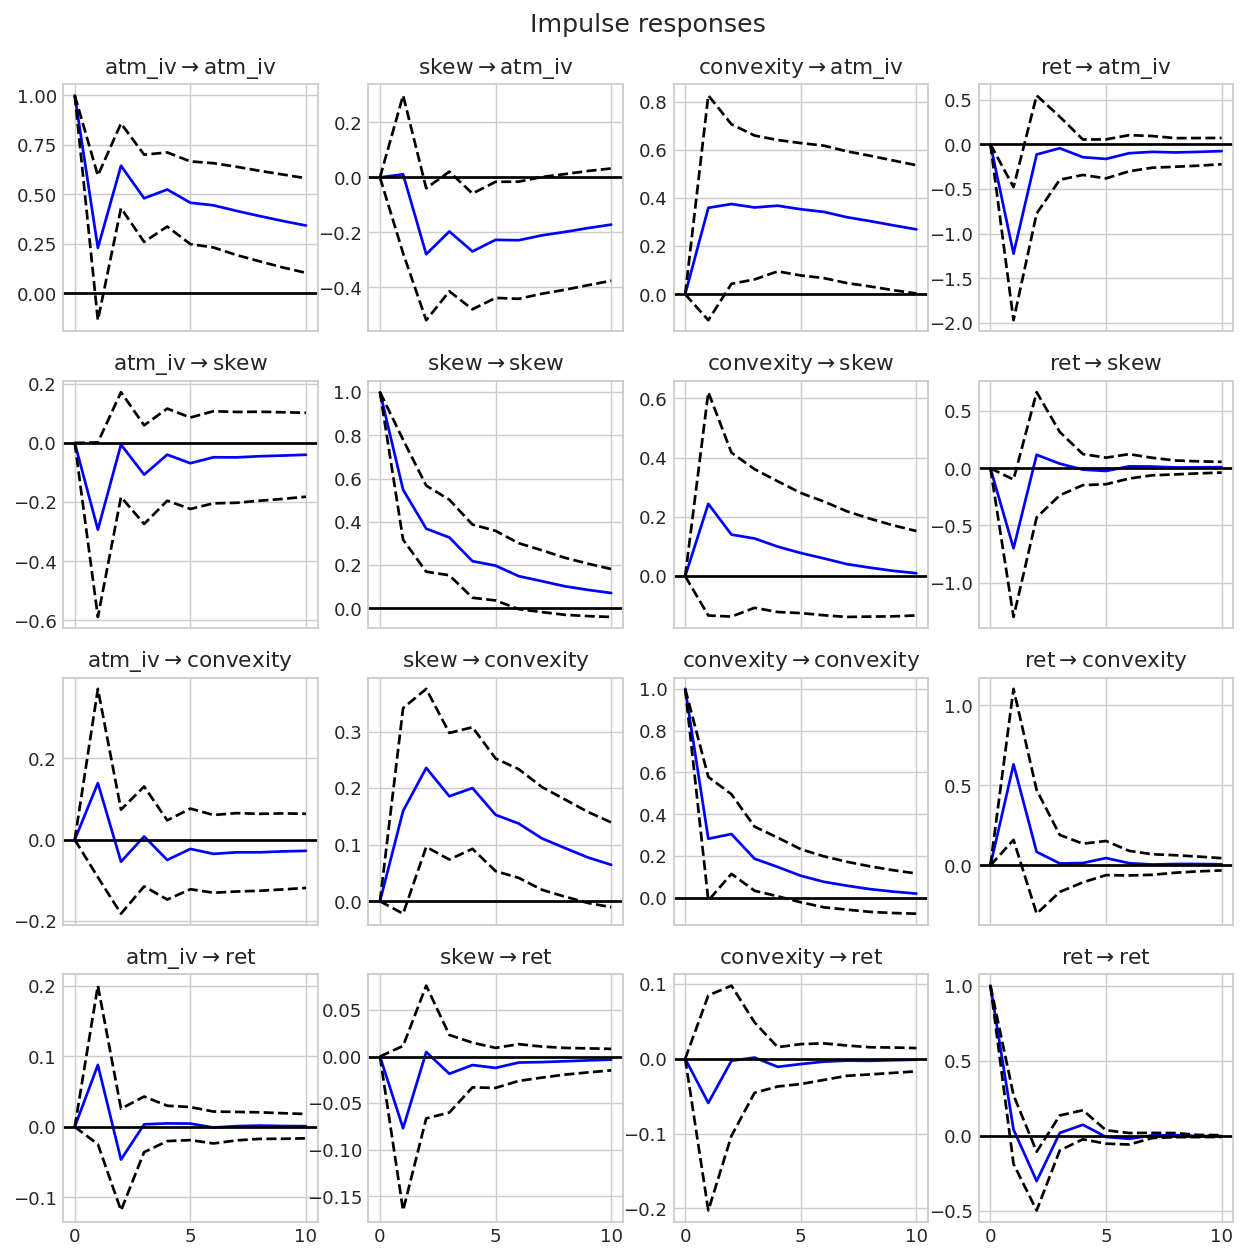

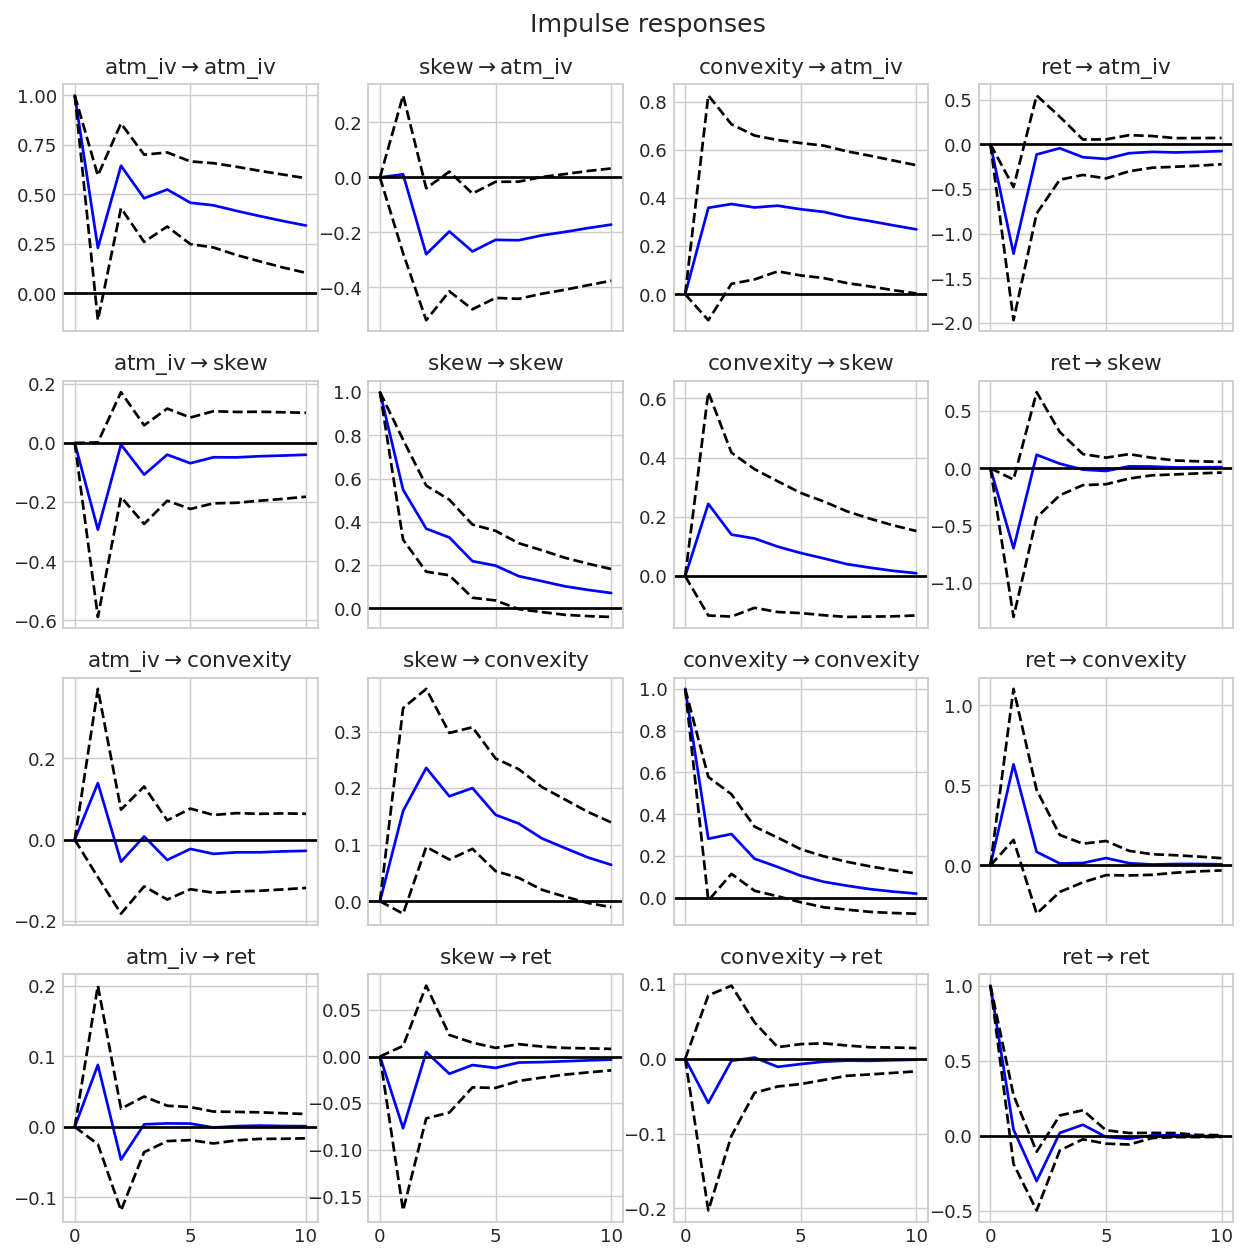

In [68]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

## Cointegration

In [48]:
# --- ENGLE-GRANGER COINTEGRATION TESTS ---
from statsmodels.tsa.stattools import coint

print("\n" + "═"*62)
print("COINTEGRATION TESTS — Engle-Granger")
print("═"*62)

# Prepare clean data
data_coint = reg[['vix', 'atm_iv', 'rv_past']].dropna()

# Test 1: VIX vs ATM_IV
score_1, pvalue_1, _ = coint(data_coint['vix'], data_coint['atm_iv'])
print(f"\n1. VIX / ATM_IV")
print(f"   Engle-Granger p-value: {pvalue_1:.4f}")
print(f"   → {'COINTEGRATED ✓' if pvalue_1 < 0.05 else 'NOT cointegrated'}")

# Test 2: VIX vs RV_past
score_2, pvalue_2, _ = coint(data_coint['vix'], data_coint['rv_past'])
print(f"\n2. VIX / RV (past)")
print(f"   Engle-Granger p-value: {pvalue_2:.4f}")
print(f"   → {'COINTEGRATED ✓' if pvalue_2 < 0.05 else 'NOT cointegrated'}")

# Test 3: ATM_IV vs RV_past
score_3, pvalue_3, _ = coint(data_coint['atm_iv'], data_coint['rv_past'])
print(f"\n3. ATM_IV / RV (past)")
print(f"   Engle-Granger p-value: {pvalue_3:.4f}")
print(f"   → {'COINTEGRATED ✓' if pvalue_3 < 0.05 else 'NOT cointegrated'}")

print("\n" + "═"*62)


══════════════════════════════════════════════════════════════
COINTEGRATION TESTS — Engle-Granger
══════════════════════════════════════════════════════════════

1. VIX / ATM_IV
   Engle-Granger p-value: 0.1168
   → NOT cointegrated

2. VIX / RV (past)
   Engle-Granger p-value: 0.0015
   → COINTEGRATED ✓

3. ATM_IV / RV (past)
   Engle-Granger p-value: 0.0025
   → COINTEGRATED ✓

══════════════════════════════════════════════════════════════


First result : surprising